# Bangla Presentation-Assist — Phases 3 → 7
Continuation of `bangla-ml-dataset.ipynb` (Phases 1–2: Whisper-small + LoRA on Common Voice Bangla is already trained).
This notebook mirrors the English notebook, adapted for Bangla:

| Phase | What this notebook does |
|---|---|
| 1 | Re-audits the data and **rebuilds the exact same held-out ASR split** (seed 42, 3000 train / 300 eval) |
| 2 | Evaluates the trained Whisper LoRA: **zero-shot vs fine-tuned** WER / CER |
| 3 | Builds a **coherent Bangla text corpus** (Bangla Wikipedia) |
| 4 | Fine-tunes **Bangla GPT-2** (causal LM) and **mT5-small** (seq2seq) for continuation |
| 6 | Integration: audio → Whisper → context → GPT-2 / mT5 suggestions (+ latency) |
| 5 | Optional Bangla TTS (MMS-TTS) — bolted on last, as in the plan |
| 7 | Evaluation: perplexity, chrF, human-eval sheet, results.json |

**Before running (Kaggle right panel):**
1. *Add Input* → **Bangla Common Voice Validated Clips** (same dataset as before)
2. *Add Input* → your **Whisper LoRA checkpoint** dataset (`checkpoint-7`, or any dataset that contains the adapter)
3. *Settings* → Accelerator **GPU (T4/P100)**, **Internet ON** (needed for Wikipedia + model downloads)
4. (Second session onwards) add the `bangla-model-output` dataset you create in the last cell — finished models are detected and training is skipped.

In [1]:
# ============================================================
# CELL 1: SETUP
# ============================================================
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"      # one GPU -> no DataParallel surprises
os.environ["TOKENIZERS_PARALLELISM"] = "false"

!pip install -q transformers peft accelerate jiwer datasets evaluate sacrebleu librosa soundfile
!pip install -U torchao jiwer accelerate bitsandbytes -q

import re, gc, glob, json, time, math, random, shutil, unicodedata
from pathlib import Path
import numpy as np
import pandas as pd
import torch

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cpu":
    print("WARNING: no GPU. Settings -> Accelerator -> GPU, then restart.")

# ── Models / paths ─────────────────────────────────────────
WORK         = "/kaggle/working"
WHISPER_BASE = "openai/whisper-small"
GPT2_BASE    = "flax-community/gpt2-bengali"   # Bangla GPT-2 pretrained on mC4-bn
MT5_BASE     = "google/mt5-small"              # multilingual (incl. Bangla), from the lit review

GPT2_OUT = f"{WORK}/gpt2-bn-continuation"
MT5_OUT  = f"{WORK}/mt5-bn-continuation"
SAVE_DIR = f"{WORK}/bangla_model_output"

# ── Switches ───────────────────────────────────────────────
N_TRAIN_ASR = 3000    # MUST match the Bangla ASR notebook (so eval clips were never trained on)
N_EVAL_ASR  = 300
RUN_MT5 = True        # set False to train only GPT-2
RUN_TTS = True        # set False to skip the optional TTS cell
CUSTOM_CORPUS_PATH = None   # optional: your own Bangla .txt (documents separated by 2 blank lines)
WHISPER_CKPT_OVERRIDE = None  # optional: exact path to a Whisper LoRA adapter folder

RESULTS = {}          # collected metrics -> results.json

# ── Path helpers (recursive, skip the huge clips folder) ───
PRUNE = {"validated_clips", "clips", "__pycache__", ".ipynb_checkpoints"}

def walk(base):
    for root, dirs, files in os.walk(base):
        dirs[:] = [d for d in dirs if d not in PRUNE]
        yield root, dirs, files

def find_first_file(filename, base="/kaggle/input"):
    for root, _, files in walk(base):
        if filename in files:
            return os.path.join(root, filename)
    return None

def find_clips_dir(cv_root):
    for base in (cv_root, os.path.dirname(cv_root)):
        for name in ("validated_clips", "clips"):
            p = os.path.join(base, name)
            if os.path.isdir(p):
                return p
    for root, _, files in os.walk(cv_root):
        if any(f.endswith((".mp3", ".wav")) for f in files[:50]):
            return root
    raise FileNotFoundError(f"No audio clips found near {cv_root}")

def find_whisper_adapter():
    if WHISPER_CKPT_OVERRIDE:
        return WHISPER_CKPT_OVERRIDE
    cands = []
    for base in (WORK, "/kaggle/input"):
        for root, _, files in walk(base):
            if "adapter_config.json" in files and "whisper" in root.lower():
                m = re.fullmatch(r"checkpoint-(\d+)", os.path.basename(root))
                step = int(m.group(1)) if m else 10**9      # a flat saved adapter beats any checkpoint
                cands.append((step, root))
    if not cands:
        raise FileNotFoundError("No Whisper LoRA adapter found. Add your checkpoint dataset as Input "
                                "or set WHISPER_CKPT_OVERRIDE.")
    cands.sort()
    return cands[-1][1]

def locate_model(name):
    # finished model folder (either .../<name>/final or a flat .../<name>) in /kaggle/working or /kaggle/input
    for base in (WORK, "/kaggle/input"):
        for root, _, files in walk(base):
            if "config.json" in files:
                if os.path.basename(root) == name:
                    return root
                if os.path.basename(root) == "final" and os.path.basename(os.path.dirname(root)) == name:
                    return root
    return None

CV_TSV = find_first_file("validated.tsv") or find_first_file("train.tsv")
if CV_TSV is None:
    raise FileNotFoundError("validated.tsv not found. Add 'Bangla Common Voice Validated Clips' as Input.")
CV_ROOT   = os.path.dirname(CV_TSV)
CLIPS_DIR = find_clips_dir(CV_ROOT)

WHISPER_CKPT = find_whisper_adapter()
GPT2_FINAL   = locate_model("gpt2-bn-continuation")
MT5_FINAL    = locate_model("mt5-bn-continuation")
GPT2_FINAL = None   # force retrain
MT5_FINAL  = None   # force retrain

print("\nCommon Voice TSV :", CV_TSV)
print("Clips dir        :", CLIPS_DIR)
print("Whisper adapter  :", WHISPER_CKPT)
print("GPT-2 finished   :", GPT2_FINAL or "not found -> will train")
print("mT5 finished     :", MT5_FINAL or ("not found -> will train" if RUN_MT5 else "disabled"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 14.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 10.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 48.7 MB/s eta 0:00:00:00:0100:01
Device: cuda

Common Voice TSV : /kaggle/input/datasets/rithikdebnath548/bangla-common-voice-validated/validated.tsv
Clips dir        : /kaggle/input/datasets/rithikdebnath548/bangla-common-voice-validated/validated_clips
Whisper adapter  : /kaggle/input/datasets/rithikdebnath548/updated-checkpoint-epoch4/bangla_model_output/whisper-bn-lora
GPT-2 finished   : not found -> will train
mT5 finished     : not

## Phase 1 — Data audit (and rebuild the exact ASR split)

In [2]:
# ============================================================
# CELL 2: PHASE 1 — DATA AUDIT + SAME HELD-OUT SPLIT AS ASR NOTEBOOK
# ============================================================
df = pd.read_csv(CV_TSV, sep="\t")
print("Columns:", list(df.columns))
print("Total rows:", len(df))
if "client_id" in df.columns:
    print("Unique speakers:", df["client_id"].nunique())
if "up_votes" in df.columns:
    print(f"Avg up_votes: {df['up_votes'].mean():.2f} | Avg down_votes: {df['down_votes'].mean():.2f}")

# identical logic to the ASR notebook -> identical shuffle -> identical eval clips
df["sentence_norm"] = df["sentence"].astype(str).apply(lambda s: unicodedata.normalize("NFC", s).strip())
if "down_votes" in df.columns:
    df_clean = df[(df["down_votes"] <= df.get("up_votes", 1)) & (df["sentence_norm"].str.len() > 0)]
else:
    df_clean = df[df["sentence_norm"].str.len() > 0]
df_clean = df_clean.copy()
df_clean["audio_path"] = df_clean["path"].apply(lambda p: os.path.join(CLIPS_DIR, p))
df_clean = df_clean[df_clean["audio_path"].apply(os.path.exists)]
print(f"Rows after quality filter + existing audio: {len(df_clean)} / {len(df)}")

df_shuffled = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)
train_df = df_shuffled.iloc[:N_TRAIN_ASR]
eval_df  = df_shuffled.iloc[N_TRAIN_ASR:N_TRAIN_ASR + N_EVAL_ASR].reset_index(drop=True)
print(f"ASR train clips: {len(train_df)} | held-out eval clips: {len(eval_df)}")

wc = df_clean["sentence_norm"].str.split().str.len()
print(f"Words per sentence: mean {wc.mean():.1f}, median {wc.median():.0f}, max {wc.max()}")

# rough clip duration from a small sample
try:
    import librosa
    durs = [librosa.get_duration(path=p) for p in df_clean["audio_path"].sample(40, random_state=1)]
    print(f"Avg clip duration (40-clip sample): {np.mean(durs):.2f}s -> ~{np.mean(durs)*len(df_clean)/3600:.1f} h total (est.)")
except Exception as e:
    print("Duration estimate skipped:", e)

# normalisation used when scoring WER (strip punctuation, collapse spaces)
_PUNCT = re.compile(r"[।,.?!;:\"'“”‘’()\[\]{}\-–—…]")
def clean_for_wer(s):
    return re.sub(r"\s+", " ", _PUNCT.sub(" ", s)).strip()

print("\nSample sentences:")
for s in df_clean["sentence_norm"].head(3):
    print("  ", s)

Columns: ['client_id', 'path', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment']
Total rows: 44739
Unique speakers: 11857
Avg up_votes: 3.86 | Avg down_votes: 0.40
Rows after quality filter + existing audio: 44111 / 44739
ASR train clips: 3000 | held-out eval clips: 300
Words per sentence: mean 9.2, median 9, max 20
Avg clip duration (40-clip sample): 5.83s -> ~71.4 h total (est.)

Sample sentences:
   গভীর জলের বার্থ ও বহুমুখী টার্মিনাল সহ, বন্দরটি দক্ষতার সাথে বিশ্বের বৃহত্তম বাল্ক ক্যারিয়ার পরিচালনা করতে সক্ষম।
   তবে কয়েক মাস পর তিনি অবসর নেন।
   এ পৌরসভার প্রশাসনিক কার্যক্রম বোয়ালখালী থানার আওতাধীন।


## Phase 2 — ASR evaluation: zero-shot vs fine-tuned Whisper (Bangla)

In [3]:
# ============================================================
# CELL 3: PHASE 2 — EVALUATE WHISPER LoRA  (baseline vs fine-tuned)
# ============================================================
import jiwer, librosa
from peft import PeftModel
from transformers import WhisperProcessor, WhisperForConditionalGeneration

processor = WhisperProcessor.from_pretrained(WHISPER_BASE, language="bn", task="transcribe")
WHISPER_GEN = dict(max_new_tokens=128)

def load_audio(path, sr=16000):
    try:
        y, _ = librosa.load(path, sr=sr, mono=True)
    except Exception:
        import torchaudio
        w, s = torchaudio.load(path)
        w = w.mean(dim=0)
        if s != sr:
            w = torchaudio.functional.resample(w, s, sr)
        y = w.numpy()
    return y

def load_whisper():
    base = WhisperForConditionalGeneration.from_pretrained(WHISPER_BASE)
    base.generation_config.language = "bn"
    base.generation_config.task = "transcribe"
    base.generation_config.forced_decoder_ids = None
    return PeftModel.from_pretrained(base, WHISPER_CKPT).to(device).eval()

def transcribe_batch(model, paths, bs=8):
    outs = []
    for i in range(0, len(paths), bs):
        audio = [load_audio(p) for p in paths[i:i + bs]]
        feats = processor.feature_extractor(audio, sampling_rate=16000,
                                            return_tensors="pt").input_features.to(device)
        with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16, enabled=(device == "cuda")):
            ids = model.generate(input_features=feats, **WHISPER_GEN)
        outs += [t.strip() for t in processor.batch_decode(ids, skip_special_tokens=True)]
    return outs

def asr_scores(refs, preds):
    out = {"wer": jiwer.wer(refs, preds), "cer": jiwer.cer(refs, preds)}
    nr = [clean_for_wer(r) for r in refs]; npd = [clean_for_wer(p) for p in preds]
    keep = [i for i, r in enumerate(nr) if r]
    out["wer_norm"] = jiwer.wer([nr[i] for i in keep], [npd[i] for i in keep])
    out["cer_norm"] = jiwer.cer([nr[i] for i in keep], [npd[i] for i in keep])
    return out

whisper_model = load_whisper()
print("Loaded Whisper + LoRA from:", WHISPER_CKPT)

EVAL_N = 100      # raise to 300 for the final report if time allows
eval_paths = eval_df["audio_path"].tolist()[:EVAL_N]
eval_refs  = eval_df["sentence_norm"].tolist()[:EVAL_N]

t0 = time.time()
with whisper_model.disable_adapter():                 # = plain pretrained Whisper-small (zero-shot baseline)
    zs_preds = transcribe_batch(whisper_model, eval_paths)
ft_preds = transcribe_batch(whisper_model, eval_paths)  # adapter ON
print(f"Evaluation took {time.time() - t0:.0f}s on {EVAL_N} held-out clips")

zs, ft = asr_scores(eval_refs, zs_preds), asr_scores(eval_refs, ft_preds)
print("\n" + "=" * 62)
print(f"{'':22}{'WER':>9}{'CER':>9}{'WER(norm)':>11}{'CER(norm)':>11}")
print(f"{'Zero-shot Whisper-small':22}{zs['wer']:>9.3f}{zs['cer']:>9.3f}{zs['wer_norm']:>11.3f}{zs['cer_norm']:>11.3f}")
print(f"{'Fine-tuned (LoRA)':22}{ft['wer']:>9.3f}{ft['cer']:>9.3f}{ft['wer_norm']:>11.3f}{ft['cer_norm']:>11.3f}")
print("=" * 62)
RESULTS["asr"] = {"n_eval_clips": EVAL_N, "whisper_adapter": WHISPER_CKPT, "zero_shot": zs, "fine_tuned": ft}

print("\nSample comparisons:")
for r, z, f in list(zip(eval_refs, zs_preds, ft_preds))[:5]:
    print("REF :", r); print("ZERO:", z); print("FT  :", f); print("-" * 60)

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Loaded Whisper + LoRA from: /kaggle/input/datasets/rithikdebnath548/updated-checkpoint-epoch4/bangla_model_output/whisper-bn-lora


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'trans

Evaluation took 87s on 100 held-out clips

                            WER      CER  WER(norm)  CER(norm)
Zero-shot Whisper-small    1.164    1.032      1.157      1.028
Fine-tuned (LoRA)         0.632    0.284      0.615      0.278

Sample comparisons:
REF : পাকিস্তান আমলে ফেনী বিমানবন্দরটি সচল করা হয়নি।
ZERO: पकेस्तनामले पेनी भीमन बन्दुत्ती शवच्योल करा हैनी
FT  : পাকিস্তান আমলে ফেনি বিমানবন্দরটি সচল করা হয়নি।
------------------------------------------------------------
REF : লরন্স অলিভিয়ে এবং স্পেন্সার ট্রেসি যৌথভাবে সর্বাধিক নয়বার মনোনয়ন পেয়েছেন।
ZERO: ,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
FT  : লোরন্স অলি ভিয়ে এবং স্পেন্সার্ক ট্রেসী যৌথ ভাবে সর্বাধীক নয়বা
------------------------------------------------------------
REF : দলে তিনি মূলতঃ বোলার হিসেবে অংশ নিয়ে থাকেন।
ZERO: ឍ្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្�
FT  : দলে তিনি মূলত বোলারিকসাবে অংশনীয়ে থাকেন।
-----------------------

In [4]:
# EXPERIMENT: is the ASR garbage caused by the decoding settings?
configs = {
    "current (rep 1.3, ngram 3)": dict(max_new_tokens=128, repetition_penalty=1.3, no_repeat_ngram_size=3),
    "no penalties":               dict(max_new_tokens=128),
    "mild ngram 10":              dict(max_new_tokens=128, no_repeat_ngram_size=10),
    "beam 4, no penalties":       dict(max_new_tokens=128, num_beams=4),
}
N = 50
orig_gen = WHISPER_GEN
for name, cfg in configs.items():
    WHISPER_GEN = cfg
    preds = transcribe_batch(whisper_model, eval_paths[:N])
    s = asr_scores(eval_refs[:N], preds)
    print(f"{name:28s} WER {s['wer']:.3f} | CER {s['cer']:.3f} | WER(norm) {s['wer_norm']:.3f}")
    print("    REF :", eval_refs[0]); print("    PRED:", preds[0])
WHISPER_GEN = orig_gen

Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


current (rep 1.3, ngram 3)   WER 1.017 | CER 0.659 | WER(norm) 1.103
    REF : পাকিস্তান আমলে ফেনী বিমানবন্দরটি সচল করা হয়নি।
    PRED: পাকেস্তাаШ আমলোল-এ ফ�ísিনি বিoncé�ারবৎদী সচল ক।রা হয়নী।


Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


no penalties                 WER 0.627 | CER 0.271 | WER(norm) 0.609
    REF : পাকিস্তান আমলে ফেনী বিমানবন্দরটি সচল করা হয়নি।
    PRED: পাকিস্তান আমলে ফেনি বিমানবন্দরটি সচল করা হয়নি।


Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


mild ngram 10                WER 0.634 | CER 0.275 | WER(norm) 0.616
    REF : পাকিস্তান আমলে ফেনী বিমানবন্দরটি সচল করা হয়নি।
    PRED: পাকিস্তান আমলে ফেনি বিমানবন্দরটি সচল করা হয়নি।


Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


beam 4, no penalties         WER 0.629 | CER 0.265 | WER(norm) 0.611
    REF : পাকিস্তান আমলে ফেনী বিমানবন্দরটি সচল করা হয়নি।
    PRED: পাকিস্তান আমলে ফেনি বিমানবন্দরটি সচল করা হয়নি।


## Phase 3 — Coherent Bangla text corpus
Common Voice sentences are unrelated to each other, so the continuation models are trained on connected text (Bangla Wikipedia). Articles are split **at article level** into train / held-out, so held-out text is never seen in training.

In [5]:
# ============================================================
# CELL 4: PHASE 3 — BANGLA TEXT CORPUS (WIKIPEDIA)
# ============================================================
from datasets import load_dataset

MIN_PARA_CHARS = 80      # drops headings / fragments
MIN_BN_RATIO   = 0.70    # share of Bangla letters in a paragraph
HELDOUT_EVERY  = 25      # every 25th article -> held-out (~4%)

NEED_TRAINING = (GPT2_FINAL is None) or (RUN_MT5 and MT5_FINAL is None)
N_ARTICLES = 20000 if NEED_TRAINING else 2500     # only held-out text is needed if models already exist

def bn_ratio(s):
    letters = [c for c in s if c.isalpha()]
    return sum("\u0980" <= c <= "\u09FF" for c in letters) / max(1, len(letters))

def clean_article(text):
    text = unicodedata.normalize("NFC", text)
    paras = []
    for p in text.split("\n"):
        p = re.sub(r"\[\d+\]", "", p)                 # citation markers
        p = re.sub(r"\s+", " ", p).strip()
        if len(p) >= MIN_PARA_CHARS and "।" in p and bn_ratio(p) >= MIN_BN_RATIO:
            paras.append(p)
    out = "\n".join(paras)
    return out if len(out) >= 200 else None

def docs_from_wikipedia(n):
    ds = load_dataset("wikimedia/wikipedia", "20231101.bn", split="train", streaming=True)
    for i, ex in enumerate(ds):
        if i >= n:
            break
        yield ex.get("text", "")

def docs_from_custom(path):
    raw = open(path, encoding="utf-8").read()
    for d in re.split(r"\n\s*\n\s*\n", raw):
        yield d

def docs_from_common_voice(n_docs=4000, sents_per_doc=6):
    # WEAK fallback: unrelated sentences glued together (only if Wikipedia is unreachable)
    sents = df_clean["sentence_norm"].drop_duplicates().tolist()
    random.Random(SEED).shuffle(sents)
    for i in range(0, min(len(sents), n_docs * sents_per_doc), sents_per_doc):
        yield " ".join(sents[i:i + sents_per_doc])

if CUSTOM_CORPUS_PATH:
    source, raw_docs = "custom file", docs_from_custom(CUSTOM_CORPUS_PATH)
else:
    try:
        raw_docs = list(docs_from_wikipedia(N_ARTICLES))
        source = "Bangla Wikipedia (wikimedia/wikipedia 20231101.bn)"
    except Exception as e:
        print("Wikipedia load failed:", repr(e)[:200])
        print(">> Falling back to Common Voice sentences (weak, incoherent). Turn Internet ON for better results.")
        raw_docs, source = list(docs_from_common_voice()), "Common Voice sentences (weak fallback)"

train_articles, heldout_articles = [], []
for i, raw in enumerate(raw_docs):
    cleaned = clean_article(raw)
    if cleaned is None:
        continue
    (heldout_articles if i % HELDOUT_EVERY == 0 else train_articles).append(cleaned)
del raw_docs

n_chars = sum(map(len, train_articles))
print("Corpus source   :", source)
print(f"Train articles  : {len(train_articles)} ({n_chars/1e6:.1f}M chars)")
print(f"Held-out articles: {len(heldout_articles)}")
RESULTS["corpus"] = {"source": source, "train_articles": len(train_articles),
                     "heldout_articles": len(heldout_articles), "train_chars": n_chars}
if train_articles:
    print("\nSample:\n", train_articles[0][:300])

README.md: 0.00B [00:00, ?B/s]

Corpus source   : Bangla Wikipedia (wikimedia/wikipedia 20231101.bn)
Train articles  : 16410 (49.7M chars)
Held-out articles: 690

Sample:
 বাংলাদেশ () দক্ষিণ এশিয়ার একটি সার্বভৌম রাষ্ট্র। বাংলাদেশের সাংবিধানিক নাম গণপ্রজাতন্ত্রী বাংলাদেশ। ভৌগোলিকভাবে বাংলাদেশের পশ্চিমে ভারতের পশ্চিমবঙ্গ, উত্তরে পশ্চিমবঙ্গ, আসাম ও মেঘালয়, পূর্ব সীমান্তে আসাম, ত্রিপুরা ও মিজোরাম, দক্ষিণ-পূর্ব সীমান্তে মিয়ানমারের চিন ও রাখাইন রাজ্য এবং দক্ষিণ উপকূলের দ


## Phase 4A — Bangla GPT-2 (causal LM, next-token objective)
The English `gpt2` tokenizer shreds Bangla into bytes, so we continue-train **`flax-community/gpt2-bengali`** (already pretrained on Bangla mC4) on the Wikipedia corpus.

In [6]:
# ============================================================
# CELL 5: PHASE 4A — FINE-TUNE BANGLA GPT-2   (skips if already trained)
# ============================================================

from transformers import (AutoTokenizer, AutoModelForCausalLM, TrainingArguments,
                          Trainer, default_data_collator)
from datasets import Dataset as HFDataset

BLOCK            = 256       # tokens per training block
MAX_TRAIN_BLOCKS = 20000     # ~5M tokens/epoch -> ~10 min on a T4; raise if quota allows
MAX_EVAL_BLOCKS  = 600
GPT2_EPOCHS      = 3

def build_blocks_list(articles, tok, block, max_blocks):
    ids, need = [], block * max_blocks
    for a in articles:
        ids.extend(tok(a, add_special_tokens=False)["input_ids"] + [tok.eos_token_id])
        if len(ids) >= need:
            break
    n = min(len(ids) // block, max_blocks)
    return [ids[i * block:(i + 1) * block] for i in range(n)]

def free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if GPT2_FINAL is not None:
    print("GPT-2 already trained — skipping Cell 5. Using:", GPT2_FINAL)
    gpt2_tok = AutoTokenizer.from_pretrained(GPT2_FINAL)
else:
    print("Starting GPT-2 training...")
    gpt2_tok = AutoTokenizer.from_pretrained(GPT2_BASE)
    gpt2_tok.model_max_length = 10**6              # we chunk manually; silence length warnings
    assert gpt2_tok.eos_token_id is not None, "tokenizer has no EOS token"
    if gpt2_tok.pad_token is None:
        gpt2_tok.pad_token = gpt2_tok.eos_token

    tr_blocks = build_blocks_list(train_articles,   gpt2_tok, BLOCK, MAX_TRAIN_BLOCKS)
    ev_blocks = build_blocks_list(heldout_articles, gpt2_tok, BLOCK, MAX_EVAL_BLOCKS)
    print(f"Blocks -> train: {len(tr_blocks)} | eval: {len(ev_blocks)}  (x{BLOCK} tokens)")
    tr_ds = HFDataset.from_dict({"input_ids": tr_blocks, "labels": tr_blocks})
    ev_ds = HFDataset.from_dict({"input_ids": ev_blocks, "labels": ev_blocks})

    gpt2_model = AutoModelForCausalLM.from_pretrained(GPT2_BASE).float()

    gpt2_args = TrainingArguments(
        output_dir=GPT2_OUT,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=GPT2_EPOCHS,
        learning_rate=5e-5,
        weight_decay=0.01,
        warmup_ratio=0.05,
        fp16=(device == "cuda"),
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        report_to="none",
    )
    gpt2_trainer = Trainer(model=gpt2_model, args=gpt2_args, train_dataset=tr_ds,
                           eval_dataset=ev_ds, data_collator=default_data_collator)
    res = gpt2_trainer.train()
    print(f"GPT-2 done | train loss {res.training_loss:.4f}")

    GPT2_FINAL = f"{GPT2_OUT}/final"
    gpt2_trainer.save_model(GPT2_FINAL)                # best checkpoint (by eval loss)
    gpt2_tok.save_pretrained(GPT2_FINAL)
    json.dump(gpt2_trainer.state.log_history, open(f"{GPT2_FINAL}/log_history.json", "w"))
    print("Saved to", GPT2_FINAL)
    del gpt2_trainer, gpt2_model, tr_ds, ev_ds, tr_blocks, ev_blocks
    free_gpu()

Starting GPT-2 training...


config.json:   0%|          | 0.00/864 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Blocks -> train: 20000 | eval: 600  (x256 tokens)


model.safetensors:   0%|          | 0.00/510M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


GPT-2 done | train loss 1.2495


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to /kaggle/working/gpt2-bn-continuation/final


## Phase 4B — mT5-small (seq2seq baseline from the literature review)
Input = previous 1–2 sentences of a paragraph → target = the next sentence. Trained in **fp32** (mT5 produces NaNs in fp16).

In [7]:
# ============================================================
# CELL 6: PHASE 4B — FINE-TUNE mT5-small   (skips if already trained / disabled)
# ============================================================ 

from transformers import (AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq,
                          Seq2SeqTrainer, Seq2SeqTrainingArguments)

MAX_PAIRS_TRAIN = 30000
MAX_PAIRS_EVAL  = 1000
MT5_EPOCHS      = 3
MT5_MAX_IN, MT5_MAX_OUT = 96, 48

def split_sentences(par):
    return [s.strip() for s in re.split(r"(?<=[।?!])\s+", par) if len(s.strip()) >= 15]

def make_pairs(articles, per_article=3, max_pairs=30000, seed=SEED):
    # (previous <=2 sentences) -> (next sentence), always inside ONE paragraph (= coherent)
    rng, pairs = random.Random(seed), []
    for art in articles:
        cand = []
        for par in art.split("\n"):
            sents = split_sentences(par)
            for i in range(1, len(sents)):
                cand.append({"input": " ".join(sents[max(0, i - 2):i]), "target": sents[i]})
        rng.shuffle(cand)
        pairs.extend(cand[:per_article])
    rng.shuffle(pairs)
    return pairs[:max_pairs]

if not RUN_MT5:
    print("RUN_MT5 = False — skipping mT5.")
    mt5_tok = None
elif MT5_FINAL is not None:
    print("mT5 already trained — skipping Cell 6. Using:", MT5_FINAL)
    mt5_tok = AutoTokenizer.from_pretrained(MT5_FINAL)
else:
    print("Starting mT5 training (fp32)...")
    mt5_tok = AutoTokenizer.from_pretrained(MT5_BASE)
    tr_pairs = make_pairs(train_articles,   per_article=3, max_pairs=MAX_PAIRS_TRAIN)
    ev_pairs = make_pairs(heldout_articles, per_article=3, max_pairs=MAX_PAIRS_EVAL, seed=123)
    print(f"Pairs -> train: {len(tr_pairs)} | eval: {len(ev_pairs)}")
    print("Example:", tr_pairs[0])

    def tok_pairs(batch):
        enc = mt5_tok(batch["input"], max_length=MT5_MAX_IN, truncation=True)
        enc["labels"] = mt5_tok(text_target=batch["target"], max_length=MT5_MAX_OUT, truncation=True)["input_ids"]
        return enc

    tr_ds = HFDataset.from_list(tr_pairs).map(tok_pairs, batched=True, remove_columns=["input", "target"])
    ev_ds = HFDataset.from_list(ev_pairs).map(tok_pairs, batched=True, remove_columns=["input", "target"])

    mt5_model = AutoModelForSeq2SeqLM.from_pretrained(MT5_BASE).float()

    mt5_args = Seq2SeqTrainingArguments(
        output_dir=MT5_OUT,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=MT5_EPOCHS,
        learning_rate=3e-4,
        weight_decay=0.01,
        warmup_ratio=0.03,
        fp16=False,                       # mT5 + fp16 = NaN loss
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        predict_with_generate=False,      # eval loss only (fast)
        report_to="none",
    )
    mt5_trainer = Seq2SeqTrainer(model=mt5_model, args=mt5_args, train_dataset=tr_ds, eval_dataset=ev_ds,
                                 data_collator=DataCollatorForSeq2Seq(mt5_tok, model=mt5_model))
    res = mt5_trainer.train()
    print(f"mT5 done | train loss {res.training_loss:.4f}")

    MT5_FINAL = f"{MT5_OUT}/final"
    mt5_trainer.save_model(MT5_FINAL)
    mt5_tok.save_pretrained(MT5_FINAL)
    json.dump(mt5_trainer.state.log_history, open(f"{MT5_FINAL}/log_history.json", "w"))
    print("Saved to", MT5_FINAL)
    del mt5_trainer, mt5_model, tr_ds, ev_ds
    free_gpu()

Starting mT5 training (fp32)...


config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

mT5 done | train loss 3.2072


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to /kaggle/working/mt5-bn-continuation/final


In [8]:
import glob, shutil
for d in glob.glob(f"{WORK}/*-continuation/checkpoint-*"):
    shutil.rmtree(d, ignore_errors=True)
print("checkpoints removed")

checkpoints removed


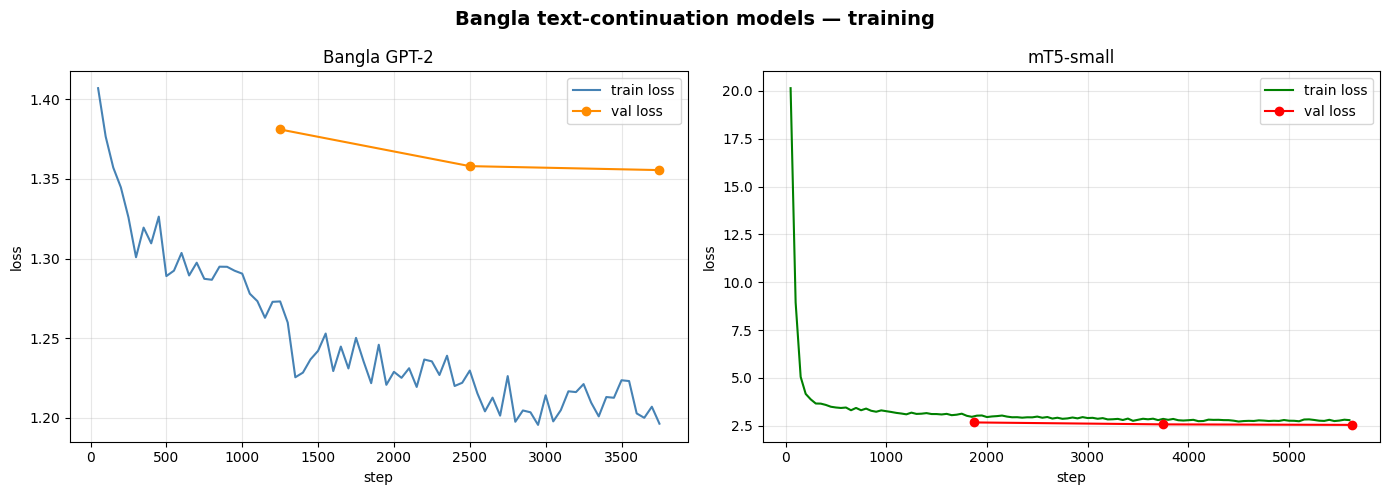

In [9]:
# ============================================================
# CELL 7: TRAINING CURVES (GPT-2 + mT5)
# ============================================================
import matplotlib.pyplot as plt

def read_log(final_dir):
    p = os.path.join(final_dir, "log_history.json") if final_dir else None
    return json.load(open(p)) if p and os.path.exists(p) else None

g_log, m_log = read_log(GPT2_FINAL), read_log(MT5_FINAL)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Bangla text-continuation models — training", fontsize=14, fontweight="bold")

for ax, log, title, c1, c2 in [(axes[0], g_log, "Bangla GPT-2", "steelblue", "darkorange"),
                               (axes[1], m_log, "mT5-small",    "green",     "red")]:
    if not log:
        ax.set_title(f"{title} (no log found)"); continue
    tr = [(e["step"], e["loss"]) for e in log if "loss" in e and "eval_loss" not in e]
    ev = [(e["step"], e["eval_loss"]) for e in log if "eval_loss" in e]
    if tr: ax.plot(*zip(*tr), color=c1, label="train loss")
    if ev: ax.plot(*zip(*ev), color=c2, marker="o", label="val loss")
    ax.set_title(title); ax.set_xlabel("step"); ax.set_ylabel("loss"); ax.grid(alpha=0.3); ax.legend()

plt.tight_layout()
plt.savefig(f"{WORK}/continuation_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Load the finished models + suggestion helpers

In [10]:
# ============================================================
# CELL 8: LOAD CONTINUATION MODELS + HELPERS
# ============================================================
gpt2_model = AutoModelForCausalLM.from_pretrained(GPT2_FINAL).float().to(device).eval()
if gpt2_tok.pad_token is None:
    gpt2_tok.pad_token = gpt2_tok.eos_token

mt5_model = None
if RUN_MT5 and MT5_FINAL:
    mt5_model = AutoModelForSeq2SeqLM.from_pretrained(MT5_FINAL).float().to(device).eval()
    mt5_tok.truncation_side = "left"      # keep the END of a long context

def trim_to_sentence(text):
    text = text.strip()
    m = re.search(r"[।?!]", text)
    return text[:m.end()].strip() if m else text

def last_context(text, max_words=40):
    # what the presenter said most recently: last 2 sentences, at most max_words words
    sents = [s for s in re.split(r"(?<=[।?!])\s+", text.strip()) if s]
    ctx = " ".join(sents[-2:])
    words = ctx.split()
    return " ".join(words[-max_words:])

def gpt2_suggest(prompt, n=3, sample=True, max_new_tokens=35):
    enc = gpt2_tok(prompt, return_tensors="pt", add_special_tokens=False)
    ids = enc["input_ids"][:, -200:].to(device)
    kw = dict(do_sample=True, top_p=0.92, temperature=0.8, num_return_sequences=n) if sample else dict(do_sample=False)
    with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16, enabled=(device == "cuda")):
        out = gpt2_model.generate(input_ids=ids, attention_mask=torch.ones_like(ids),
                                  max_new_tokens=max_new_tokens, repetition_penalty=1.2,
                                  no_repeat_ngram_size=3, pad_token_id=gpt2_tok.eos_token_id, **kw)
    return [gpt2_tok.decode(o[ids.shape[1]:], skip_special_tokens=True).strip() for o in out]

def mt5_suggest(context, n=3, sample=True, max_new_tokens=MT5_MAX_OUT):
    if mt5_model is None:
        return []
    enc = mt5_tok(context, return_tensors="pt", truncation=True, max_length=MT5_MAX_IN).to(device)
    kw = dict(do_sample=True, top_p=0.92, temperature=0.9, num_return_sequences=n) if sample else dict(num_beams=1, do_sample=False)
    with torch.no_grad():
        out = mt5_model.generate(**enc, max_new_tokens=max_new_tokens, no_repeat_ngram_size=3, **kw)
    return [t.strip() for t in mt5_tok.batch_decode(out, skip_special_tokens=True)]

print("GPT-2 params:", sum(p.numel() for p in gpt2_model.parameters()) // 10**6, "M")
if mt5_model is not None:
    print("mT5   params:", sum(p.numel() for p in mt5_model.parameters()) // 10**6, "M")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


GPT-2 params: 124 M
mT5   params: 556 M


## Phase 7 — Evaluate the continuation models
Perplexity (GPT-2 only; **not comparable to mT5** because the tokenizers differ), chrF on held-out *prefix → next sentence*, qualitative prompts, and a human-rating sheet (LaMDA-style fluency / relevance).

In [11]:
# ============================================================
# CELL 9: PHASE 7 — CONTINUATION EVALUATION
# ============================================================
import pandas as pd
from sacrebleu.metrics import CHRF

# ---- 1. Perplexity on held-out Wikipedia (GPT-2: fine-tuned vs original) ----
@torch.no_grad()
def perplexity(model, blocks, bs=16):
    tot, cnt = 0.0, 0
    for i in range(0, len(blocks), bs):
        batch = torch.tensor(blocks[i:i + bs]).to(device)
        with torch.autocast("cuda", dtype=torch.float16, enabled=(device == "cuda")):
            loss = model(input_ids=batch, labels=batch).loss.float().item()
        n = batch.numel() - batch.shape[0]
        tot += loss * n; cnt += n
    return math.exp(tot / cnt)

held_blocks = build_blocks_list(heldout_articles, gpt2_tok, BLOCK, MAX_EVAL_BLOCKS)
ppl_ft = perplexity(gpt2_model, held_blocks)
base_lm = AutoModelForCausalLM.from_pretrained(GPT2_BASE).float().to(device).eval()
ppl_base = perplexity(base_lm, held_blocks)
del base_lm; free_gpu()
print(f"GPT-2 held-out perplexity ({len(held_blocks)} blocks): original {ppl_base:.2f} -> fine-tuned {ppl_ft:.2f}")

# ---- 2. chrF on held-out (prefix -> next sentence) --------------------------
eval_pairs = make_pairs(heldout_articles, per_article=2, max_pairs=150, seed=7)
refs = [p["target"] for p in eval_pairs]
chrf = CHRF()

g_hyp = [trim_to_sentence(gpt2_suggest(p["input"], n=1, sample=False, max_new_tokens=40)[0]) for p in eval_pairs]
res = {"gpt2_chrF": chrf.corpus_score(g_hyp, [refs]).score}
m_hyp = None
if mt5_model is not None:
    m_hyp = [mt5_suggest(p["input"], n=1, sample=False)[0] for p in eval_pairs]
    res["mt5_chrF"] = chrf.corpus_score(m_hyp, [refs]).score
copy_hyp = [split_sentences(p["input"])[-1] for p in eval_pairs]                 # "just repeat the last sentence"
res["copy_last_sentence_chrF"] = chrf.corpus_score(copy_hyp, [refs]).score
shuf = refs[:]; random.Random(0).shuffle(shuf)
res["random_sentence_chrF"] = chrf.corpus_score(shuf, [refs]).score             # floor
print("\nchrF on", len(eval_pairs), "held-out pairs (higher = closer to the real next sentence):")
for k, v in res.items():
    print(f"  {k:26s} {v:6.2f}")
print("(Open-ended continuation has many valid answers, so chrF is only a RELATIVE signal — use the human sheet too.)")

RESULTS["continuation"] = {"gpt2_ppl_original": ppl_base, "gpt2_ppl_finetuned": ppl_ft, **res,
                           "note": "perplexities of GPT-2 and mT5 are not comparable (different tokenizers)"}

# ---- 3. Qualitative: presentation-style prompts -----------------------------
prompts = [
    "আজকের উপস্থাপনার মূল বিষয় হলো",
    "উপসংহারে বলা যায় যে",
    "গবেষণার ফলাফল থেকে দেখা যায় যে",
    "সাম্প্রতিক গবেষণা অনুযায়ী",
    "বাংলাদেশের অর্থনীতিতে কৃষির ভূমিকা অনেক গুরুত্বপূর্ণ।",
]
print("\n" + "=" * 70)
for p in prompts:
    print("PROMPT :", p)
    for i, s in enumerate(gpt2_suggest(p, n=2), 1):
        print(f"  GPT-2 #{i}: {s}")
    for i, s in enumerate(mt5_suggest(p, n=2), 1):
        print(f"  mT5   #{i}: {s}")
    print("-" * 70)

# ---- 4. Human-evaluation sheet (rate 1-5, fill in Excel / Sheets) ----------
n_sheet = 30
sheet = pd.DataFrame({
    "prefix": [p["input"] for p in eval_pairs[:n_sheet]],
    "real_next_sentence": refs[:n_sheet],
    "gpt2_suggestion": g_hyp[:n_sheet],
    "mt5_suggestion": (m_hyp or [""] * len(eval_pairs))[:n_sheet],
})
for c in ("gpt2_fluency", "gpt2_relevance", "mt5_fluency", "mt5_relevance"):
    sheet[c] = ""
sheet.to_csv(f"{WORK}/human_eval_sheet.csv", index=False, encoding="utf-8-sig")
print(f"\nSaved human_eval_sheet.csv ({n_sheet} rows) — rate fluency & relevance 1–5 for the write-up.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: flax-community/gpt2-bengali
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT-2 held-out perplexity (600 blocks): original 4.43 -> fine-tuned 3.90

chrF on 150 held-out pairs (higher = closer to the real next sentence):
  gpt2_chrF                   11.14
  mt5_chrF                    22.02
  copy_last_sentence_chrF     20.07
  random_sentence_chrF        12.58
(Open-ended continuation has many valid answers, so chrF is only a RELATIVE signal — use the human sheet too.)

PROMPT : আজকের উপস্থাপনার মূল বিষয় হলো
  GPT-2 #1: ‘বাংলাদেশ’ সম্পর্কে একটি বিতর্ক। সুপ্রীম কোর্ট
  GPT-2 #2: ‘বাংলাদেশের সংস্কৃতি, নৈতিকতা, মুক্তচিন্তা-চ
  mT5   #1: এই উপস্থাপনার আজকের উপস্থাপনা প্রথম ক্ষেত্রে একটি প্রধান উপস্থাপককে সংগঠনের সূচনা হিসেবে আজকে প্রয়োজনীয় হিসে
  mT5   #2: এই প্রধান কারণ হচ্ছে "এর প্রয়োজনীয় এবং বর্তমান ভূমিকা পালন করতে"।
----------------------------------------------------------------------
PROMPT : উপসংহারে বলা যায় যে
  GPT-2 #1: ভারতীয় উপমহাদেশে কোন বিজ্ঞানসম্মত সূত্র প্রমাণ ছ
  GPT-2 #2: তিনি তাঁর ধর্মীয় পুনরুত্থানকে দৃঢ় করেছিলেন।
  mT5   #1: বলা হয

In [12]:
!pip install -q -U openai google-genai
from kaggle_secrets import UserSecretsClient
_secrets = UserSecretsClient()

OPENAI_MODEL = "gpt-4o-mini"        # <-- put a chat model that exists on YOUR OpenAI account
GEMINI_MODEL = "gemini-2.5-flash"   # <-- check Google AI Studio for the current Flash name

openai_client = gemini_client = None
try:
    from openai import OpenAI
    openai_client = OpenAI(api_key=_secrets.get_secret("OPENAI_API_KEY"))
except Exception as e:
    print("OpenAI disabled:", repr(e)[:150])
try:
    from google import genai
    gemini_client = genai.Client(api_key=_secrets.get_secret("GEMINI_API_KEY"))
except Exception as e:
    print("Gemini disabled:", repr(e)[:150])

SYSTEM_PROMPT = ("You help a presenter who is speaking Bangla. You get the last words they said. "
                 "Write ONLY the single next sentence they are likely to say, in Bangla. No explanation.")
FEW_SHOT = [
    ("বাংলাদেশ দক্ষিণ এশিয়ার একটি দেশ। এর রাজধানী ঢাকা।",
     "ঢাকা দেশের বৃহত্তম শহর এবং প্রধান বাণিজ্যিক কেন্দ্র।"),
    ("আজকের আলোচনায় আমরা পরিবেশ দূষণ নিয়ে কথা বলব।",
     "প্রথমে দেখা যাক দূষণের প্রধান কারণগুলো কী কী।"),
]
_warned = set()
def _fail(name, e):
    if name not in _warned:
        _warned.add(name); print(f"[{name}] call failed (shown once):", repr(e)[:200])
    return ""

def openai_suggest(ctx):
    if openai_client is None: return ""
    msgs = [{"role": "system", "content": SYSTEM_PROMPT}]
    for c, t in FEW_SHOT:
        msgs += [{"role": "user", "content": c}, {"role": "assistant", "content": t}]
    msgs.append({"role": "user", "content": ctx})
    try:
        r = openai_client.chat.completions.create(model=OPENAI_MODEL, messages=msgs)
        return trim_to_sentence(r.choices[0].message.content or "")
    except Exception as e:
        return _fail("openai", e)

def gemini_suggest(ctx):
    if gemini_client is None: return ""
    prompt = SYSTEM_PROMPT + "\n\n" + "\n".join(f"Said: {c}\nNext: {t}" for c, t in FEW_SHOT) + f"\nSaid: {ctx}\nNext:"
    try:
        r = gemini_client.models.generate_content(model=GEMINI_MODEL, contents=prompt)
        return trim_to_sentence(r.text or "")
    except Exception as e:
        return _fail("gemini", e)

print("OpenAI:", OPENAI_MODEL if openai_client else "off", "| Gemini:", GEMINI_MODEL if gemini_client else "off")
print("test ->", openai_suggest("আজকের উপস্থাপনার মূল বিষয় হলো বাংলা ভাষা।")[:80])
print("test ->", gemini_suggest("আজকের উপস্থাপনার মূল বিষয় হলো বাংলা ভাষা।")[:80])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 462.2 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 2.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 10.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.6/95.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.4/83.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.0/345.0 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.6/472.6 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 47.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 4.0 MB/s eta 0:00:00
ERROR: pip's depe

In [15]:
N_API = 50
api_pairs, api_refs = eval_pairs[:N_API], refs[:N_API]

def run_api(fn):
    outs, times = [], []
    for p in api_pairs:
        t0 = time.perf_counter(); outs.append(fn(p["input"])); times.append(time.perf_counter() - t0)
    return outs, float(np.mean(times))

hyps = {"gpt2 (local)": g_hyp[:N_API]}
if m_hyp: hyps["mt5 (local)"] = m_hyp[:N_API]
lat = {}
for name, fn, client in [("openai (API)", openai_suggest, openai_client),
                         ("gemini (API)", gemini_suggest, gemini_client)]:
    if client is not None:
        hyps[name], lat[name] = run_api(fn)

shuf = api_refs[:]; random.Random(0).shuffle(shuf)
hyps["copy last sentence"] = copy_hyp[:N_API]
hyps["random sentence"] = shuf

print(f"chrF on the same {N_API} held-out pairs:")
cmp = {}
for name, h in hyps.items():
    cmp[name] = chrf.corpus_score(h, [api_refs]).score
    extra = f" | avg latency {lat[name]:.2f}s" if name in lat else ""
    print(f"  {name:20s} {cmp[name]:6.2f}{extra}")
print("NOTE: Wikipedia is probably in the API models' training data, so this is NOT a clean held-out test for them.")
RESULTS["api_comparison"] = {"n_pairs": N_API, "chrF": cmp, "avg_latency_s": lat,
                             "openai_model": OPENAI_MODEL, "gemini_model": GEMINI_MODEL}

for key, col in [("openai (API)", "openai_suggestion"), ("gemini (API)", "gemini_suggestion")]:
    if key in hyps:
        sheet[col] = (hyps[key] + [""] * len(sheet))[:len(sheet)]
        sheet[col.replace("suggestion", "fluency")] = ""
        sheet[col.replace("suggestion", "relevance")] = ""
sheet.to_csv(f"{WORK}/human_eval_sheet.csv", index=False, encoding="utf-8-sig")
print("human_eval_sheet.csv updated.")

chrF on the same 50 held-out pairs:
  gpt2 (local)          11.34
  mt5 (local)           18.80
  copy last sentence    20.06
  random sentence       20.86
NOTE: Wikipedia is probably in the API models' training data, so this is NOT a clean held-out test for them.
human_eval_sheet.csv updated.


## Phase 6 — Integration pipeline
clip audio → Whisper (Bangla) → last words → GPT-2 / mT5 suggestions. Latency is measured per stage (after one warm-up call).

In [16]:
# ============================================================
# CELL 10: PHASE 6 — INTEGRATION (Whisper + GPT-2 + mT5)
# ============================================================
def _sync():
    if device == "cuda":
        torch.cuda.synchronize()

def presentation_assist(wav_path):
    _sync(); t0 = time.perf_counter()
    transcript = transcribe_batch(whisper_model, [wav_path], bs=1)[0]
    _sync(); t1 = time.perf_counter()
    ctx = last_context(transcript)
    g = [trim_to_sentence(s) for s in gpt2_suggest(ctx, n=3)]
    _sync(); t2 = time.perf_counter()
    m = mt5_suggest(ctx, n=3) if mt5_model is not None else []
    _sync(); t3 = time.perf_counter()
    return {"transcript": transcript, "context": ctx, "gpt2": g, "mt5": m,
            "t_asr": t1 - t0, "t_gpt2": t2 - t1, "t_mt5": t3 - t2}

demo = eval_df.sample(4, random_state=3).reset_index(drop=True)
_ = presentation_assist(demo["audio_path"][0])        # warm-up (not timed)

lat = []
for _, row in demo.iterrows():
    r = presentation_assist(row["audio_path"])
    lat.append((r["t_asr"], r["t_gpt2"], r["t_mt5"]))
    print("=" * 70)
    print("REFERENCE  :", row["sentence_norm"])
    print("TRANSCRIPT :", r["transcript"])
    for i, s in enumerate(r["gpt2"], 1): print(f"GPT-2 #{i}   :", s)
    for i, s in enumerate(r["mt5"], 1):  print(f"mT5   #{i}   :", s)
    print(f"latency    : ASR {r['t_asr']:.2f}s | GPT-2 {r['t_gpt2']:.2f}s | mT5 {r['t_mt5']:.2f}s")

lat = np.array(lat)
print("\nMean latency over", len(lat), "clips -> ASR %.2fs | GPT-2 %.2fs | mT5 %.2fs | total (ASR+GPT-2) %.2fs"
      % (lat[:, 0].mean(), lat[:, 1].mean(), lat[:, 2].mean(), lat[:, 0].mean() + lat[:, 1].mean()))
RESULTS["latency_seconds"] = {"asr": float(lat[:, 0].mean()), "gpt2": float(lat[:, 1].mean()),
                              "mt5": float(lat[:, 2].mean()), "device": device}
last_demo = r

Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


REFERENCE  : এরপর তিনি চলে যান অস্ট্রেলিয়ায়।
TRANSCRIPT : প্রিপর তিনি চোলীয়ান অস্ট্রী লিয়ায়।
GPT-2 #1   : মাদুশাঙ্গ, যে বৌদ্ধ সম্প্রদায়ের নেতৃস্থা
GPT-2 #2   : চুতারার মেম বিশ্বে প্রসিদ্ধ সংগীতজ্ঞ ও গীত
GPT-2 #3   : তার প্রকৃত নাম ছিল চুজাই সোলজান।
mT5   #1   : তিনি রয়লা বিশ্ববিদ্যালয়ের এর নাম হিসেবে তাকে এই প্রতিষ্ঠা করেন।
mT5   #2   : তখন তার বাড়ি থেকে ২০০৪ সালে তিনি নোবেল পুরস্কার অর্জন করেন।
mT5   #3   : তিনি নর্থ দ্য দ্য কাইস্ট অস্ট্রীলিয়া লেখার মাধ্যমে এর অবস্থান ছিল।
latency    : ASR 1.80s | GPT-2 0.43s | mT5 0.54s


Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


REFERENCE  : এছাড়াও তিনি ডানহাতে অফ ব্রেক বোলিং করে থাকেন।
TRANSCRIPT : এছাড়াও তিনি দান হাতে ওআপ-রেক বোলিং করে থাকেন।
GPT-2 #1   : হিমাগার পর্বতের শীর্ষে উঠে নিজের কোমর ছুঁয়ে দি
GPT-2 #2   : ব্যাংকক পাওয়ার কোম্পানী ( বি. এন.সি) লিমিটেড এর স
GPT-2 #3   : বাংলাদেশ ক্রীড়া শিল্পী সমিতি বাংলা, ইংরেজি, এব
mT5   #1   : তিনি বাবা বাবা হিসেবে নিযুক্ত হন।
mT5   #2   : তিনি বেশ কয়েকটি ক্ষেত্রে পরিচালক হিসেবে একাধিক কাজ করেন।
mT5   #3   : তিনি তারপর ১৭ বছর বয়সে তার পরীক্ষার পর নিউইয়র্ক বিশ্ববিদ্যালয়ের সঙ্গে কাজ করেন।
latency    : ASR 2.14s | GPT-2 0.42s | mT5 0.58s


Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


REFERENCE  : নির্দিষ্ট মানচিত্রের অনুমান বা স্কেল দ্বারা পৃথিবীকে সবচেয়ে সঠিক উপায়ে প্রদর্শন করার উপায়গুলি অন্যান্য প্রকারের চেয়ে বেশি সুপরিচিত এবং ব্যবহৃত।
TRANSCRIPT : নিদ্দিষ্ট মাঞ্চিতে অনভাই স্কেল দ্বারে পৃথিবেক সবচেস্য উপয়ে প�
GPT-2 #1   : চৌবে দেবতা, সর্প দৈববাণী দ্ধারক পাখি, চাঁদবীজী (চি
GPT-2 #2   : E‐l বেগেরূপে একটি অনুজ্বল পদার্থ আছে, যার নাম হল ল
GPT-2 #3   : হো চু বেইজিং-এ।
mT5   #1   : এর বর্তমান দৈর্ঘ্য হলো:
mT5   #2   : এই শিকলটি কবরের সাথে এই সমুদ্র সমতল বৃহত্তম মাঞ্চ, সেতু, উত্তর চট্টগ্রাম, নেপাল, পশ্চিমে দক্ষিণে অক্ষাংশ
mT5   #3   : এই মাঞ্চিকে এই পঞ্চাশেরও বেশি ঘাট ছাড়াই আংশিক সবচেয়ে উচ্চ এবং প্রায় ৬০০ মিটার দূরে এব
latency    : ASR 3.05s | GPT-2 0.42s | mT5 0.82s
REFERENCE  : গুরুত্বপূর্ণ বিষয় হল জলের গভীরতা।
TRANSCRIPT : গুরুত প্রণে বিষয় হল জলের গোভীরতা।
GPT-2 #1   : এই স্থানে কাদা, শুঁড়ের ছোঁয়া ও চাঁদের আলোর মতো গোপন শক
GPT-2 #2   : খাবার শেষ করার পর তাদের কাছ থেকে সংযুক্ত কূপে
GPT-2 #3   : দাবি করা হয়, এগুলো ছিল এক ধরনের স্নায়ুতন্ত্র যা মূলত
mT5   #

## Phase 5 — Optional text-to-speech (integration only)
Uses the pretrained `facebook/mms-tts-ben` Bangla VITS model — no training.

In [17]:
# ============================================================
# CELL 11: PHASE 5 — OPTIONAL BANGLA TTS
# ============================================================
if RUN_TTS:
    try:
        from transformers import VitsModel
        from IPython.display import Audio, display
        from scipy.io import wavfile

        tts_tok   = AutoTokenizer.from_pretrained("facebook/mms-tts-ben")
        tts_model = VitsModel.from_pretrained("facebook/mms-tts-ben").to(device).eval()

        text_to_speak = (last_demo["gpt2"] or [""])[0] or "আজকের উপস্থাপনার মূল বিষয় হলো বাংলা ভাষা।"
        print("Speaking:", text_to_speak)
        enc = tts_tok(text_to_speak, return_tensors="pt").to(device)
        with torch.no_grad():
            wav = tts_model(**enc).waveform[0].cpu().numpy()
        sr = tts_model.config.sampling_rate
        wavfile.write(f"{WORK}/tts_demo.wav", sr, wav)
        display(Audio(wav, rate=sr))
        RESULTS["tts"] = {"model": "facebook/mms-tts-ben", "ok": True}
        del tts_model; free_gpu()
    except Exception as e:
        print("TTS skipped (not critical):", repr(e)[:300])
        RESULTS["tts"] = {"ok": False, "error": repr(e)[:200]}
else:
    print("RUN_TTS = False — skipped.")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/927 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/47.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/145M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

Speaking: এই স্থানে কাদা, শুঁড়ের ছোঁয়া ও চাঁদের আলোর মতো গোপন শক


## Save everything as one downloadable ZIP
Upload the ZIP as a Kaggle dataset named **`bangla-model-output`**; next session, add it as Input and training is skipped automatically.

In [18]:
# ============================================================
# CELL 12: SAVE MODELS (FP16 for size) + RESULTS -> ONE ZIP
# ============================================================
from IPython.display import display, FileLink

if os.path.exists(SAVE_DIR):
    shutil.rmtree(SAVE_DIR)
os.makedirs(SAVE_DIR)

SKIP = {"optimizer.pt", "optimizer.bin", "scheduler.pt", "scaler.pt",
        "rng_state.pth", "trainer_state.json", "training_args.bin"}

def copy_dir(src, dst):
    os.makedirs(dst, exist_ok=True)
    for name in os.listdir(src):
        if name in SKIP:
            continue
        s, d = os.path.join(src, name), os.path.join(dst, name)
        shutil.copytree(s, d) if os.path.isdir(s) else shutil.copy2(s, d)

def export_fp16(src, dst, auto_cls):
    os.makedirs(dst, exist_ok=True)
    tok = AutoTokenizer.from_pretrained(src)
    m = auto_cls.from_pretrained(src).float().half()
    m.save_pretrained(dst, safe_serialization=True)
    tok.save_pretrained(dst)
    if os.path.exists(os.path.join(src, "log_history.json")):
        shutil.copy2(os.path.join(src, "log_history.json"), dst)
    del m; free_gpu()

print("1/3 Whisper LoRA adapter ...");  copy_dir(WHISPER_CKPT, f"{SAVE_DIR}/whisper-bn-lora")
print("2/3 GPT-2 (fp16) ...");          export_fp16(GPT2_FINAL, f"{SAVE_DIR}/gpt2-bn-continuation", AutoModelForCausalLM)
if RUN_MT5 and MT5_FINAL:
    print("3/3 mT5 (fp16) ...");        export_fp16(MT5_FINAL, f"{SAVE_DIR}/mt5-bn-continuation", AutoModelForSeq2SeqLM)

for f in ("continuation_curves.png", "human_eval_sheet.csv", "tts_demo.wav"):
    if os.path.exists(f"{WORK}/{f}"):
        shutil.copy2(f"{WORK}/{f}", SAVE_DIR)
json.dump(RESULTS, open(f"{SAVE_DIR}/results.json", "w"), indent=2, ensure_ascii=False)
open(f"{SAVE_DIR}/README.txt", "w").write(
    "Bangla presentation-assist models.\n"
    "Weights are stored in fp16 to save space. ALWAYS load with .float() (mT5 is unstable in fp16):\n"
    "  AutoModelForCausalLM.from_pretrained(path).float()\n"
    "Whisper: WhisperForConditionalGeneration.from_pretrained('openai/whisper-small') + PeftModel.from_pretrained(base, 'whisper-bn-lora')\n")

shutil.make_archive(SAVE_DIR, "zip", WORK, "bangla_model_output")
zip_path = SAVE_DIR + ".zip"
print(f"\nZIP size: {os.path.getsize(zip_path)/1024**2:.0f} MB")
display(FileLink(zip_path, result_html_prefix="Download: "))

print("\n=== RESULTS SUMMARY ===")
print(json.dumps(RESULTS, indent=2, ensure_ascii=False))

1/3 Whisper LoRA adapter ...
2/3 GPT-2 (fp16) ...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

3/3 mT5 (fp16) ...


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


ZIP size: 1154 MB


/kaggle/working/bangla_model_output.zip


=== RESULTS SUMMARY ===
{
  "asr": {
    "n_eval_clips": 100,
    "whisper_adapter": "/kaggle/input/datasets/rithikdebnath548/updated-checkpoint-epoch4/bangla_model_output/whisper-bn-lora",
    "zero_shot": {
      "wer": 1.1638418079096045,
      "cer": 1.0318386397732955,
      "wer_norm": 1.156774916013438,
      "cer_norm": 1.0275557067528491
    },
    "fine_tuned": {
      "wer": 0.631638418079096,
      "cer": 0.28404734122353725,
      "wer_norm": 0.6147816349384099,
      "cer_norm": 0.27827861881272326
    }
  },
  "corpus": {
    "source": "Bangla Wikipedia (wikimedia/wikipedia 20231101.bn)",
    "train_articles": 16410,
    "heldout_articles": 690,
    "train_chars": 49669824
  },
  "continuation": {
    "gpt2_ppl_original": 4.430736085278125,
    "gpt2_ppl_finetuned": 3.8995162375055368,
    "gpt2_chrF": 11.139452318937435,
    "mt5_chrF": 22.01622302073392,
    "copy_last_sentence_chrF": 20.070928661646644,
    "random_sentence_chrF": 12.583549699789657,
    "note": "per